In [1]:
import pandas as pd
import numpy as np

t9 = pd.read_csv('https://raw.githubusercontent.com/prvshnat/hsedata2425/refs/heads/main/table9.csv')
t10 = pd.read_csv('https://raw.githubusercontent.com/prvshnat/hsedata2425/refs/heads/main/table10.csv')

In [2]:
t9

,Date,High
0,2010-12-06,2.096667
1,2013-10-10,11.716667
2,2013-01-22,2.370000
3,2012-04-19,2.228667
4,2015-07-24,18.072666
...,...,...
1995,2016-02-09,10.652667
1996,2017-01-24,16.986668
1997,2021-12-03,363.526672
1998,2019-01-30,20.600000


In [3]:
t10

,Date,Low
0,2010-06-30,1.553333
1,2010-07-01,1.351333
2,2010-07-02,1.247333
3,2010-07-06,1.055333
4,2010-07-07,0.998667
...,...,...
3072,2022-09-13,290.399994
3073,2022-09-14,291.640015
3074,2022-09-15,300.720001
3075,2022-09-16,295.600006


In [4]:
# df = pd.concat([t9, t10])
# df.Date = pd.to_datetime(df.Date)
t9.Date = pd.to_datetime(t9.Date)
t10.Date = pd.to_datetime(t10.Date)

In [7]:
df_ = t9.merge(t10, on='Date', how='inner')

df_[df_.Date.dt.month == 11].Low.mean()

np.float64(43.138582880794694)

In [8]:
df_['month'] = df_.Date.dt.month

In [18]:
df_gr = df_.groupby('month').agg({'High': 'mean', 'Low': 'mean'})
df_gr['diff'] = df_gr['High'] - df_gr['Low']

df_gr.reset_index()

,month,High,Low,diff
0,1,46.137261,43.685291,2.451971
1,2,57.509734,54.633369,2.876365
2,3,52.167901,49.277068,2.890832
3,4,61.954756,59.119471,2.835285
4,5,55.782925,52.885933,2.896992
5,6,49.998026,47.918233,2.079792
6,7,52.269514,49.870276,2.399238
7,8,58.518952,56.547062,1.971890
8,9,56.640650,54.467354,2.173296
9,10,43.119586,41.689487,1.430099


<Axes: >

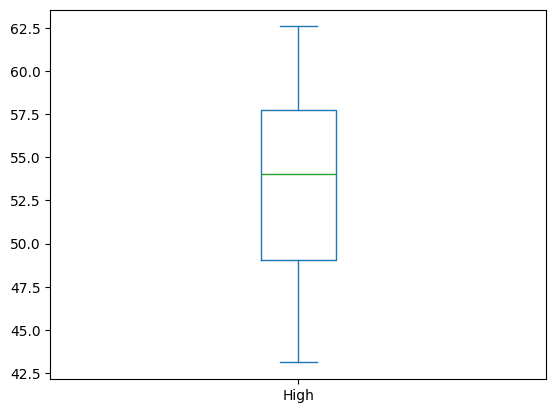

In [19]:
df_gr.High.plot(kind='box')

In [20]:
df_gr

,High,Low,diff
month,,,
1,46.137261,43.685291,2.451971
2,57.509734,54.633369,2.876365
3,52.167901,49.277068,2.890832
4,61.954756,59.119471,2.835285
5,55.782925,52.885933,2.896992
6,49.998026,47.918233,2.079792
7,52.269514,49.870276,2.399238
8,58.518952,56.547062,1.971890
9,56.640650,54.467354,2.173296
